<a href="https://colab.research.google.com/github/Greeshma-babu/AI_Projects/blob/main/ImageClassification_Animal_Bird_Person_ResNet_18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets,transforms,models
import os

In [59]:
from google.colab import files
uploaded = files.upload()

Saving Datasets_Bird_Animal_Person.zip to Datasets_Bird_Animal_Person.zip


In [60]:
import zipfile

with zipfile.ZipFile("Datasets_Bird_Animal_Person.zip", "r") as zip_ref:
    zip_ref.extractall()

In [61]:
import os
print(os.listdir())

['.config', 'Dog_classification_model.pth', 'Datasets_Bird_Animal_Person.zip', 'New_datasets', 'datasets', 'New_datasets.zip', 'Test_Dog_Image (1).jpg', 'datasets.zip', 'Datasets_Bird_Animal_Person', 'Test_Dog_Image.jpg', 'sample_data']


In [62]:
import os

for root, dirs, files in os.walk("Datasets_Bird_Animal_Person"):
    print(root, "->", dirs, files[:3])

Datasets_Bird_Animal_Person -> ['val', 'train'] []
Datasets_Bird_Animal_Person/val -> ['Bird', 'Animal', 'Person'] []
Datasets_Bird_Animal_Person/val/Bird -> [] ['3.jpg', '2.jpg', '1.jpg']
Datasets_Bird_Animal_Person/val/Animal -> [] ['3.jpg', '2.jpg', '1.jpg']
Datasets_Bird_Animal_Person/val/Person -> [] ['3.jpg', '2.jpg', '1.jpg']
Datasets_Bird_Animal_Person/train -> ['Bird', 'Animal', 'Person'] []
Datasets_Bird_Animal_Person/train/Bird -> [] ['3.jpg', '2.jpg', '4.jpg']
Datasets_Bird_Animal_Person/train/Animal -> [] ['3.jpg', '2.jpg', '4.jpg']
Datasets_Bird_Animal_Person/train/Person -> [] ['3.jpg', '2.jpg', '4.jpg']


In [63]:
import os

print("datasets:")
print(os.listdir("Datasets_Bird_Animal_Person"))

print("\ntrain:")
print(os.listdir("Datasets_Bird_Animal_Person/train"))

print("\nval:")
print(os.listdir("Datasets_Bird_Animal_Person/val"))

datasets:
['val', 'train']

train:
['Bird', 'Animal', 'Person']

val:
['Bird', 'Animal', 'Person']


In [64]:
# Define data transformations for data Augumentation and Normalization
# transforms.ToTensor() is used to convert an image into a PyTorch tensor,
# because NN in PyTorch cannot process images in their original format (such as PIL images or NumPy arrays).
# Converts the image to a PyTorch Tensor PIL Image → torch.Tensor, Scales pixel values from [0, 255] to [0.0, 1.0]
# Normalize() expects a tensor, not a PIL image.
# This normalization makes the input distribution similar to what many pretrained models (such as ResNet and VGG) expect.

data_transforms ={
    'train' : transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ]),
  'val': transforms.Compose([
      transforms.Resize(256),
      transforms.CenterCrop(224),
      transforms.ToTensor(),
      transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
  ])
}

In [80]:
# Create the data loader
data_dir = 'Datasets_Bird_Animal_Person' # Define the data directory
# ImageFolder() expects two arguments: folder path, transform
Image_dataset = {
    x : datasets.ImageFolder(
        os.path.join(data_dir, x),
        data_transforms[x])
    for x in ['train', 'val']
}

In [81]:
dataloader = {
    x: torch.utils.data.DataLoader(
        Image_dataset[x],
        batch_size=4,
        shuffle=True,
        num_workers=4)
    for x in ['train', 'val']
}
datasets_sizes = {
    x: len(Image_dataset[x])
    for x in ['train', 'val']
}
print("datasets_sizes=", datasets_sizes)
class_names = Image_dataset['train'].classes
print("Output_Labels= ",  class_names)

datasets_sizes= {'train': 15, 'val': 9}
Output_Labels=  ['Animal', 'Bird', 'Person']


**Load Pretrained Model**

In [82]:
model = models.resnet18(pretrained=True)

In [95]:

# Replace the final layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 3)

**Freeze all layers Except Final layer**

In [96]:
for name, param in model.named_parameters():
  if 'fc' in name: # fc means the fully connected layer - final classification layer
    param.requires_grad=True # Update the weight during training
  else:
    param.requires_grad=False # Freeze the weight
# Freeze will prevent training the pretrained knowledge
# Forozen layer acts as a feature extractor
# Final layer learns your dataset


**Define Loss Function**

In [97]:
criterion = nn.CrossEntropyLoss()
# CrossEntropyLoss - used for multi class classification problems
# It give the output value and label
# Softmax is an activation function that converts the model's output (called logits)
# into probabilities. between 0 and 1 and sum is 1.
# Example: The model's raw outputs (logits) are [2.5, 1.2, 0.3] -> softmax activation converts [2.5, 1.2, 0.3]

**Define Optimizer**

In [98]:
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
# The optimizer uses the gradients to change the model's weights.
# old weight -> Gradient calculate -> Optimizer -> New weight
# SGD - Stochastic Gradient descent - updates the weights during training
# lr = Learning Rate → How much the model's weights change after each update.
# momentum = Memory of previous steps → Which direction the optimizer keeps moving.

**Move Model to Device (GPU/CPU)**

In [99]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)
# Check if GPU is available True -NVIDIA GPU is available

**Steps:**


1. Loop over Epochs
2. Training & Validation phases
3. Set model mode
4. Initialize Metrics
5. Loop Over Data
6. Move data to device
7. Reset Gradient
8. Forward Pass + Loss Computation
9. Backprogation (Training Only)
10. Compute Epoch Metrics




In [100]:
num_epochs = 10
for epoch in range(num_epochs):
  for phase in ['train', 'val']:
    if phase == 'train':
      model.train()
    else :
      model.eval()
    running_loss = 0.0 # Tracks total loss across all batch
    running_correct = 0 # Counts corectly predicted samples

    for input, label in dataloader[phase]:
      inputs = input.to(device) # Move data to device. Already moved model to device.
      labels = label.to(device) # Move label to device
      optimizer.zero_grad() # Reset the gradients to zero
      with torch.set_grad_enabled(phase == 'train'):
        outputs = model(inputs) #
        _,preds = torch.max(outputs,1)
        loss = criterion(outputs, labels)
        torch.set_grad_enabled(mode=True)
        if phase == 'train':
          loss.backward() # Compute gradient
          optimizer.step() #Update the model weights
        running_loss += loss.item() * input.size(0) # Converts tensor to scalar value , Batch Size
        running_correct +=torch.sum(preds == labels.data) # Count the correct predictions
        epoch_loss = running_loss / datasets_sizes[phase] # Accuray loss
        epoch_acc = running_correct.double()/datasets_sizes[phase] # Accuary over entire datasets
        print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
print("### TRAINING COMPLETED !!!")





train Loss: 0.3338 Acc: 0.0667
train Loss: 0.5939 Acc: 0.1333
train Loss: 0.9324 Acc: 0.2667
train Loss: 1.2363 Acc: 0.2667
val Loss: 0.5475 Acc: 0.1111
val Loss: 1.0343 Acc: 0.2222
val Loss: 1.2170 Acc: 0.2222
train Loss: 0.2719 Acc: 0.2000
train Loss: 0.5541 Acc: 0.2667
train Loss: 0.8143 Acc: 0.4000
train Loss: 1.0360 Acc: 0.4667
val Loss: 0.5119 Acc: 0.1111
val Loss: 0.9763 Acc: 0.4444
val Loss: 1.0862 Acc: 0.4444
train Loss: 0.2485 Acc: 0.1333
train Loss: 0.5409 Acc: 0.2000
train Loss: 0.7275 Acc: 0.4000
train Loss: 0.9479 Acc: 0.4667
val Loss: 0.3022 Acc: 0.4444
val Loss: 0.6733 Acc: 0.7778
val Loss: 0.7333 Acc: 0.8889
train Loss: 0.2862 Acc: 0.1333
train Loss: 0.5091 Acc: 0.3333
train Loss: 0.6281 Acc: 0.6000
train Loss: 0.7438 Acc: 0.8000
val Loss: 0.2754 Acc: 0.3333
val Loss: 0.5151 Acc: 0.7778
val Loss: 0.6370 Acc: 0.7778
train Loss: 0.1611 Acc: 0.2667
train Loss: 0.3000 Acc: 0.5333
train Loss: 0.5110 Acc: 0.7333
train Loss: 0.6597 Acc: 0.8667
val Loss: 0.2954 Acc: 0.4444
val

In [101]:
torch.save(model.state_dict(), "Animal_Bird_Person_classification_model.pth")
# Save the model

**Classification on Unseen Image**

In [103]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
# transforms for preprocess the image
# torch.nn-> Used for neural network layer
# PIL -> Used to load and handle image files

**Load Model Architecture**

In [104]:
model = models.resnet18(pretrained=True)

**Model Final Layer**

In [105]:
model.fc = nn.Linear(model.fc.in_features,3)
# Datasets : Bird, Animal, Person


**Load Trained Weights**

In [106]:
model.load_state_dict(torch.load("Animal_Bird_Person_classification_model.pth"))
#torch.load(path, map_location=device)

<All keys matched successfully>

**Set model too Evaluation Mode**

In [107]:
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

**Image Preprocessing**

In [120]:
from google.colab import files
uploaded = files.upload()
image_name = list(uploaded.keys())[0]   # Get the uploaded filename
image = Image.open(image_name).convert("RGB")

Saving Person_Test.jpg to Person_Test.jpg


In [121]:
preprocess = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ]
)
input_tensor = preprocess(image)
input_batch = input_tensor.unsqueeze(0) # Add a batch dimensions
# Even for a single image, we need to pass a batch

**Disable Gradient Computation & Predict the class index**

In [122]:
with torch.no_grad(): # Turned off the gradient
  output = model(input_batch) # logits from the model
  _,predicted_class = output.max(1)
  print(predicted_class)

tensor([2])


**Map index to class name from class index**

In [123]:
class_names = ['Animal', 'Bird', 'Person']
print(f'The predicted class is {predicted_class}')

predicted_label = class_names[predicted_class.item()]
print(f"Predicted class: {predicted_label}")

The predicted class is tensor([2])
Predicted class: Person


**Find probabilties**

In [124]:
probs = torch.softmax(output, dim=1)
print("Probabilties=", probs)

Probabilties= tensor([[0.0318, 0.0741, 0.8941]])


**Predicted Image**

Text(0, 0, 'Predicted: Person')

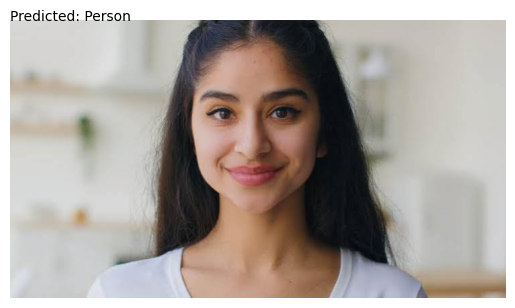

In [125]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
image = np.array(image)
plt.imshow(image)
plt.axis('off')
plt.text(0,0,f'Predicted: {predicted_label}')